# MarketScout: Перевірка дрейфу моделі

**Мета цього ноутбука:** взяти вже задеплоєну модель (`catboost_car_price_model.cbm`,
натреновану в травні на `cars_dataset.csv`) і прогнати її `.predict()` **без перенавчання**
на нових, вересневих даних — щоб побачити, наскільки якість передбачень змінилась з часом.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from catboost import CatBoostRegressor
import joblib

CURRENT_YEAR = 2026

LUXURY_MARKS = {
    'Aston Martin', 'BMW-Alpina', 'Lamborghini', 'Rolls-Royce', 'Ferrari',
    'Bentley', 'Porsche', 'Maserati', 'Lexus', 'Land Rover', 'Jaguar',
    'Mercedes-Benz', 'BMW', 'Audi', 'Lucid', 'Genesis',
}
AUTOMATIC_LIKE = {'Автомат', 'Типтронік', 'Варіатор', 'Робот'}

# Метрики травневого hold-out з main.ipynb (для порівняння нижче)
OLD_MAE, OLD_MAPE, OLD_R2, OLD_MEDIAN_AE = 2967.34, 22.65, 0.8713, 1360.60

## Завантаження замороженої моделі й довідників

In [2]:
model = CatBoostRegressor()
model.load_model("../src/backend/models/catboost_car_price_model.cbm")
valid_categories = joblib.load("../src/backend/models/valid_categories.pkl")

print(f"Модель завантажено. Марок у valid_categories.pkl: {len(valid_categories['valid_marks'])}")

Модель завантажено. Марок у valid_categories.pkl: 143


## Завантаження нових (вересневих) даних

Файл уже приведено до старої схеми колонок (`Mark`, `Model`, `Mileage`, `Fuel`, `Gearbox` —
так само, як у `cars_dataset.csv`), тому окреме перейменування `Fuel_Name`→`Fuel` тощо тут
не потрібне — лишається тільки прибрати службову колонку `Unnamed: 0`.

In [3]:
data = pd.read_csv("../data/new_clean_data_20.csv", low_memory=False)
df = data.drop(columns=['Unnamed: 0'], errors='ignore').copy()

print(f"Розмір нового датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
display(df.head(3))

Розмір нового датасету: 20000 рядків, 8 колонок


,ID,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
0,40427785,Peugeot,307,2005,3800,160,Бензин,Ручна / Механіка
1,40427759,BMW,X3,2021,29985,79,"Бензин, 2 л.",Автомат
2,40427740,Audi,A5,2020,30999,67,"Бензин, 1.98 л.",Автомат


## Очищення - ідентично до `main.ipynb`

Та сама послідовність кроків, що й для травневих даних: без цього порівняння метрик було б
нечесним (модель оцінювалась би на іншому розподілі даних, ніж той, для якого вона
готувалась).

In [4]:
df = df.drop(columns=['ID', 'Engine'], errors='ignore')
df = df[df['Price_USD'] > 0].copy()

before_trailers = len(df)
df = df[df['Mark'] != 'Причеп'].copy()
print(f"Прибрано причепів: {before_trailers - len(df)}")

df['Age'] = CURRENT_YEAR - df['Year']
df = df[(df['Age'] >= 0) & (df['Age'] <= 46)].copy()
print(f"Після фільтрації за віком: {len(df)} рядків")

Прибрано причепів: 4
Після фільтрації за віком: 19854 рядків


In [5]:
split_data = df['Fuel'].str.split(', ', expand=True)
raw_fuel_type = split_data[0]
engine_from_split = pd.to_numeric(
    split_data[1].str.replace(' л.', '', regex=False), errors='coerce'
) if 1 in split_data.columns else pd.Series(np.nan, index=df.index)

looks_like_engine = raw_fuel_type.str.match(r'^\d+(\.\d+)?\s*л\.?$', na=False)
df['Fuel_Type'] = np.where(looks_like_engine, 'Не вказано', raw_fuel_type)

engine_from_type = pd.to_numeric(raw_fuel_type.str.replace(' л.', '', regex=False), errors='coerce')
df['Engine_Capacity'] = np.where(looks_like_engine, engine_from_type, engine_from_split)
df['Engine_Capacity'] = df['Engine_Capacity'].fillna(0)
print(f"Виправлено рядків з некоректним Fuel_Type: {looks_like_engine.sum()}")

Виправлено рядків з некоректним Fuel_Type: 244


In [6]:
df['Km_per_Year'] = df['Mileage'] / (df['Age'] + 1)
df['is_EV'] = (df['Fuel_Type'] == 'Електро').astype(int)
df['is_suspicious_mileage'] = ((df['Age'] > 10) & (df['Mileage'] < 50)).astype(int)
df['is_new'] = (df['Age'] <= 3).astype(int)

df['Mark'] = df['Mark'].fillna('Other')
df['Model'] = df['Model'].fillna('Other')
df['Gearbox'] = df['Gearbox'].fillna('Unknown')

before = len(df)
df = df[
    (df['Price_USD'] >= 1000) &
    (df['Price_USD'] <= 250000) &
    (df['Engine_Capacity'] <= 10)
].copy()
print(f"Відфільтровано {before - len(df)} записів. Залишилось: {len(df)}")

df['is_luxury_brand'] = df['Mark'].isin(LUXURY_MARKS).astype(int)
df['is_automatic_gearbox'] = df['Gearbox'].isin(AUTOMATIC_LIKE).astype(int)
df['Engine_missing'] = (df['Engine_Capacity'] == 0).astype(int)
df['log_Mileage'] = np.log1p(df['Mileage'])
df['Age_x_Mileage'] = df['Age'] * df['Mileage']
df['Decade'] = (df['Year'] // 10 * 10).astype(int)

Відфільтровано 407 записів. Залишилось: 19447


In [7]:
features = [
    'Mark', 'Model', 'Mileage', 'Gearbox', 'Age',
    'Fuel_Type', 'Engine_Capacity', 'Km_per_Year',
    'is_EV', 'is_suspicious_mileage', 'is_new',
    'is_luxury_brand', 'Engine_missing', 'log_Mileage', 'Age_x_Mileage', 'Decade',
    'is_automatic_gearbox',
]
X_new = df[features]
y_new = df['Price_USD']

print(f"Ознаки ({len(features)}): {features}")
print(f"Розмір X_new: {X_new.shape}")

Ознаки (17): ['Mark', 'Model', 'Mileage', 'Gearbox', 'Age', 'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV', 'is_suspicious_mileage', 'is_new', 'is_luxury_brand', 'Engine_missing', 'log_Mileage', 'Age_x_Mileage', 'Decade', 'is_automatic_gearbox']
Розмір X_new: (19447, 17)


## Прогноз замороженою моделлю на нових даних

In [8]:
y_pred_log = model.predict(X_new)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_new, y_pred)
mape = mean_absolute_percentage_error(y_new, y_pred) * 100
r2 = r2_score(y_new, y_pred)
median_ae = np.median(np.abs(y_new.values - y_pred))

print(f"{'═'*50}")
print(f"  ЗАМОРОЖЕНА МОДЕЛЬ (травень) НА НОВИХ ДАНИХ (вересень)")
print(f"{'─'*50}")
print(f"  MAE     : {mae:,.2f} USD")
print(f"  MAPE    : {mape:.2f}%")
print(f"  R²      : {r2:.4f}")
print(f"  MedianAE: {median_ae:,.2f} USD")
print(f"{'═'*50}")

══════════════════════════════════════════════════
  ЗАМОРОЖЕНА МОДЕЛЬ (травень) НА НОВИХ ДАНИХ (вересень)
──────────────────────────────────────────────────
  MAE     : 3,140.16 USD
  MAPE    : 23.27%
  R²      : 0.8370
  MedianAE: 1,374.20 USD
══════════════════════════════════════════════════


## Порівняння з травневим hold-out

In [9]:
print(f"{'Метрика':<10} {'Травень (hold-out)':>20} {'Вересень (той же .cbm)':>25} {'Δ':>12}")
print("─" * 70)
print(f"{'MAE':<10} {OLD_MAE:>17,.0f} USD {mae:>22,.0f} USD {(mae-OLD_MAE)/OLD_MAE*100:>+10.1f}%")
print(f"{'MAPE':<10} {OLD_MAPE:>19.2f}% {mape:>24.2f}% {mape-OLD_MAPE:>+10.2f} п.п.")
print(f"{'R²':<10} {OLD_R2:>20.4f} {r2:>25.4f} {r2-OLD_R2:>+11.4f}")
print(f"{'MedianAE':<10} {OLD_MEDIAN_AE:>17,.0f} USD {median_ae:>22,.0f} USD {(median_ae-OLD_MEDIAN_AE)/OLD_MEDIAN_AE*100:>+10.1f}%")

Метрика      Травень (hold-out)    Вересень (той же .cbm)            Δ
──────────────────────────────────────────────────────────────────────
MAE                    2,967 USD                  3,140 USD       +5.8%
MAPE                     22.65%                    23.27%      +0.62 п.п.
R²                       0.8713                    0.8370     -0.0343
MedianAE               1,361 USD                  1,374 USD       +1.0%


## Прогноз vs Реальність, і розподіл залишків

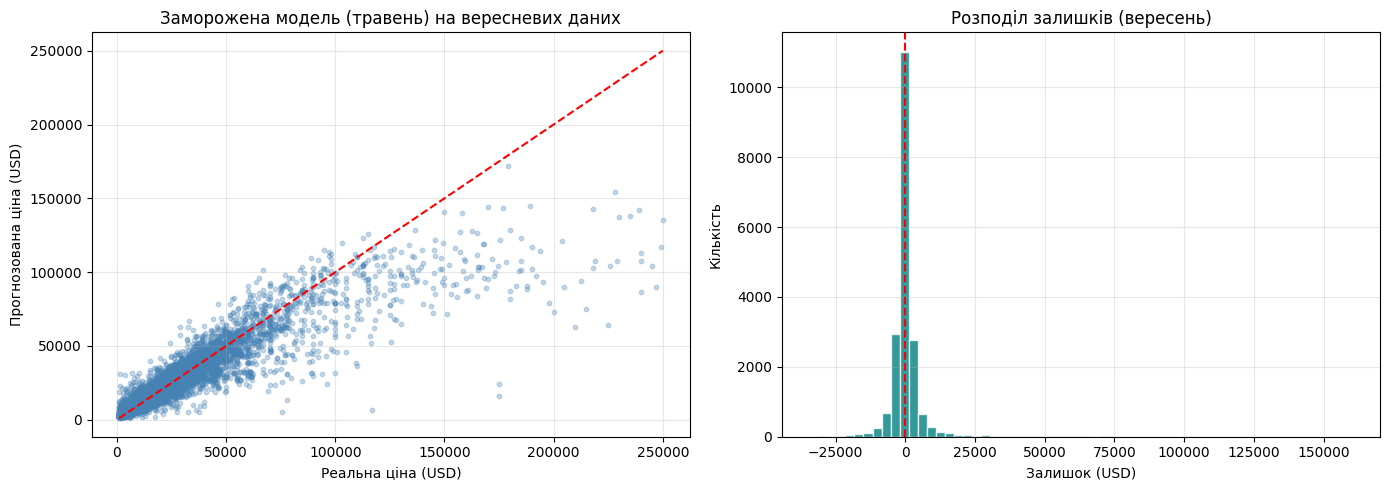

In [10]:
residuals = y_new.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_new, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_new.min(), y_new.max()], [y_new.min(), y_new.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Реальна ціна (USD)')
axes[0].set_ylabel('Прогнозована ціна (USD)')
axes[0].set_title('Заморожена модель (травень) на вересневих даних')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Залишок (USD)')
axes[1].set_ylabel('Кількість')
axes[1].set_title('Розподіл залишків (вересень)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Висновок

Помірний, але реальний дрейф присутній: **MAE зріс на ~5-6%**, а **R² помітно просів**
(більше, ніж різниця між фолдами CV у попередніх експериментах, де std R² складав
~0.03) — тобто це вже схоже не на шум, а на справжнє, хоч і некритичне, погіршення.

Ймовірні причини просідання R²:
- ринок міг зсунутися за 4 місяці (ціни, популярність моделей, курс валют);
- вересневий датасет може мати дещо інший склад (інший парсер).

**Практичний висновок:** перенавчання на нових даних - виправдане й своєчасне. І сенс
матиме окремо зберегти сам поріг `MIN_COUNT`/список `valid_marks` як артефакт разом з
новою моделлю, щоб наступного разу дрейф можна було перевірити коректніше, без цього
застереження.